# Track Dataset — Data Cleaning & Preprocessing
> **Mục tiêu:** Chuẩn bị dataset sạch để train Machine Learning model phân loại `Class`  
> **Dataset:** `train.csv` — 14,396 rows × 18 columns  
> **Target:** `Class` (0–10, multi-class classification)

---
## Tổng quan vấn đề phát hiện (Dựa theo DataProfiling và Univariate Analysis)

| # | Feature | Vấn đề | Tỷ lệ bị ảnh hưởng |
|---|---------|---------|---------------------|
| 1 | `Popularity` | Missing values | 2.31% (333 rows) |
| 2 | `key` | Missing values | 11.18% (1,609 rows) |
| 3 | `instrumentalness` | Missing values | 24.60% (3,541 rows) |
| 4 | `duration_in min/ms` | **Mixed units** — 14.4% giá trị ở dạng phút, 85.6% ở dạng milliseconds | 2,075 rows |
| 5 | `loudness` | 7 giá trị dương bất thường (loudness thông thường âm) | 0.05% |
| 6 | `speechiness`, `instrumentalness`, `liveness` | Outliers đáng kể theo IQR | 11–13% |
| 7 | `Class` | Imbalanced — Class 10 chiếm 27.5%, Class 3/4 chỉ ~2% | — |


In [85]:
# Khai báo thư viện
print('Đang khai báo thư viện')

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mstats
from datetime import datetime

print('Khai báo thư viện thành công')

Đang khai báo thư viện
Khai báo thư viện thành công


In [86]:
# Chọn dataset để xử lý

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Đang khai báo dữ liệu')

# Dữ liệu thô ban đầu
file_path = os.path.join("Data", "Data-processed", "train.csv")
# file_path = os.path.join("Data", "train.csv") # Đây là dữ liệu thô, chưa tách ra train và validation

df = pd.read_csv(file_path)
print(f"Shape: {df.shape}")

df_beforeMixDuration = df.copy()

print('Khai báo thành công')


Đang khai báo dữ liệu
Shape: (11516, 18)
Khai báo thành công


In [87]:
df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,11516.0000,11241.0000,11516.0000,11516.0000,10249.0000,11516.0000,11516.0000,11516.0000,11516.0000,8689.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000
mean,7202.1212,44.6447,0.5437,0.6623,5.9697,-7.8961,0.6376,0.0802,0.2467,0.1789,0.1956,0.4848,122.7491,200321.0849,3.9271,6.6957
std,4168.5708,17.4904,0.1656,0.2363,3.2018,4.0538,0.4807,0.0848,0.3112,0.3053,0.1595,0.2398,29.5924,113137.6604,0.3549,3.2060
min,1.0000,1.0000,0.0596,0.0012,1.0000,-39.9520,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,30.5570,0.5017,1.0000,0.0000
25%,3563.5000,33.0000,0.4320,0.5078,3.0000,-9.5400,0.0000,0.0349,0.0045,0.0001,0.0973,0.2960,99.8328,165223.5000,4.0000,5.0000
50%,7253.5000,44.0000,0.5450,0.6995,6.0000,-7.0100,1.0000,0.0474,0.0811,0.0040,0.1290,0.4790,120.0485,209213.0000,4.0000,8.0000
75%,10819.2500,56.0000,0.6590,0.8600,9.0000,-5.1617,1.0000,0.0832,0.4310,0.2040,0.2550,0.6700,142.0023,252397.2500,4.0000,10.0000
max,14395.0000,100.0000,0.9890,1.0000,11.0000,1.3420,1.0000,0.9370,0.9960,0.9870,0.9920,0.9860,217.4160,1477187.0000,5.0000,10.0000


In [88]:
# Thống kê missing value

missing_df = pd.DataFrame({
    'dtype': df.dtypes,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing_df[missing_df['missing_count'] > 0])

print(f"Duplicate rows: {df.duplicated().sum()}")
print("\n" + "=" * 50)
print(df['Class'].value_counts().sort_index())


                    dtype  missing_count  missing_pct
Popularity        float64            275       2.3900
key               float64           1267      11.0000
instrumentalness  float64           2827      24.5500
Duplicate rows: 0

Class
0      400
1      878
2      814
3      258
4      248
5      926
6     1655
7      369
8     1186
9     1615
10    3167
Name: count, dtype: int64


In [89]:
df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,11516.0000,11241.0000,11516.0000,11516.0000,10249.0000,11516.0000,11516.0000,11516.0000,11516.0000,8689.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000
mean,7202.1212,44.6447,0.5437,0.6623,5.9697,-7.8961,0.6376,0.0802,0.2467,0.1789,0.1956,0.4848,122.7491,200321.0849,3.9271,6.6957
std,4168.5708,17.4904,0.1656,0.2363,3.2018,4.0538,0.4807,0.0848,0.3112,0.3053,0.1595,0.2398,29.5924,113137.6604,0.3549,3.2060
min,1.0000,1.0000,0.0596,0.0012,1.0000,-39.9520,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,30.5570,0.5017,1.0000,0.0000
25%,3563.5000,33.0000,0.4320,0.5078,3.0000,-9.5400,0.0000,0.0349,0.0045,0.0001,0.0973,0.2960,99.8328,165223.5000,4.0000,5.0000
50%,7253.5000,44.0000,0.5450,0.6995,6.0000,-7.0100,1.0000,0.0474,0.0811,0.0040,0.1290,0.4790,120.0485,209213.0000,4.0000,8.0000
75%,10819.2500,56.0000,0.6590,0.8600,9.0000,-5.1617,1.0000,0.0832,0.4310,0.2040,0.2550,0.6700,142.0023,252397.2500,4.0000,10.0000
max,14395.0000,100.0000,0.9890,1.0000,11.0000,1.3420,1.0000,0.9370,0.9960,0.9870,0.9920,0.9860,217.4160,1477187.0000,5.0000,10.0000


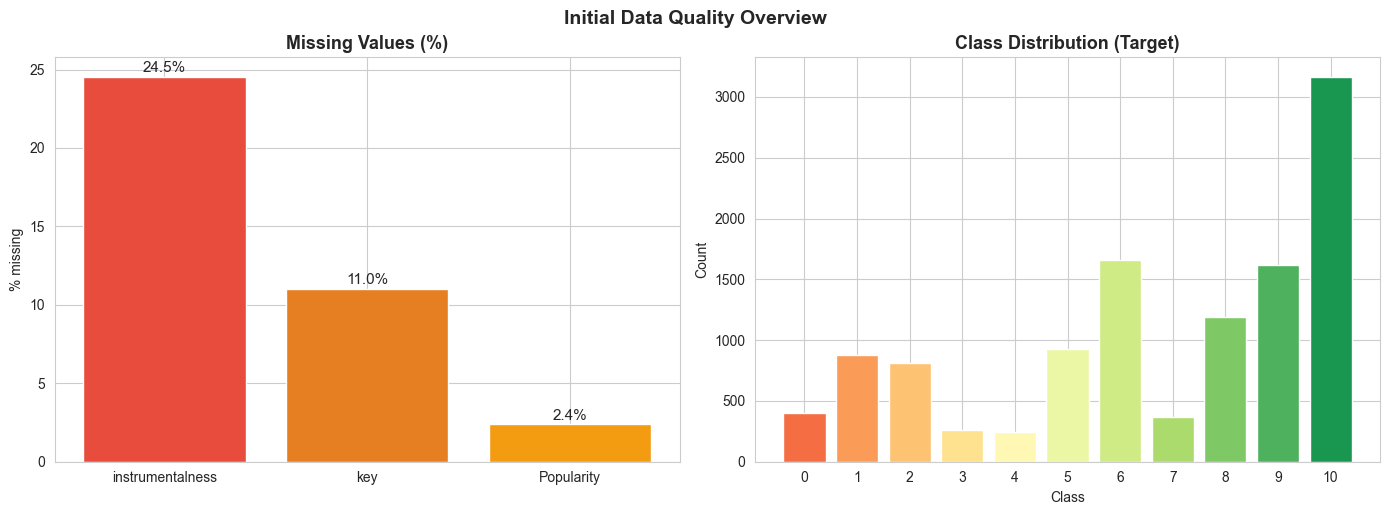

In [90]:
# Khởi tạo biểu đồ cho missing value và class distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missing values
missing_pct = (df.isnull().sum() / len(df) * 100)
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
axes[0].bar(missing_pct.index, missing_pct.values, color=['#e74c3c','#e67e22','#f39c12'])
axes[0].set_title('Missing Values (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% missing')
for i, v in enumerate(missing_pct.values):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

# Class distribution
class_counts = df['Class'].value_counts().sort_index()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(class_counts)))
axes[1].bar(class_counts.index, class_counts.values, color=colors)
axes[1].set_title('Class Distribution (Target)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticks(class_counts.index)

plt.tight_layout()
plt.suptitle('Initial Data Quality Overview', y=1.02, fontsize=14, fontweight='bold')
plt.show()


## Xử lý `duration_in min/ms`: Mixed Units

### Vấn đề
Cột `duration_in min/ms` có **hai đơn vị khác nhau** trong cùng một cột:
- **~85.6% giá trị** ở dạng **milliseconds** (ms) — ví dụ: `204947.0`, `191956.0`
- **~14.4% giá trị** ở dạng **phút** (minutes) — ví dụ: `3.893`, `4.347`

Threshold phân biệt: giá trị < 100 được coi là phút (bài nhạc ngắn nhất thực tế ~0.5 phút, dài nhất ~30 phút).

### Phương pháp xử lý
**Convert toàn bộ về milliseconds**, sau đó đổi tên cột thành `duration_ms` cho rõ ràng.

Values in milliseconds : 9,847 (85.5%)
Values in minutes      : 1,669 (14.5%)


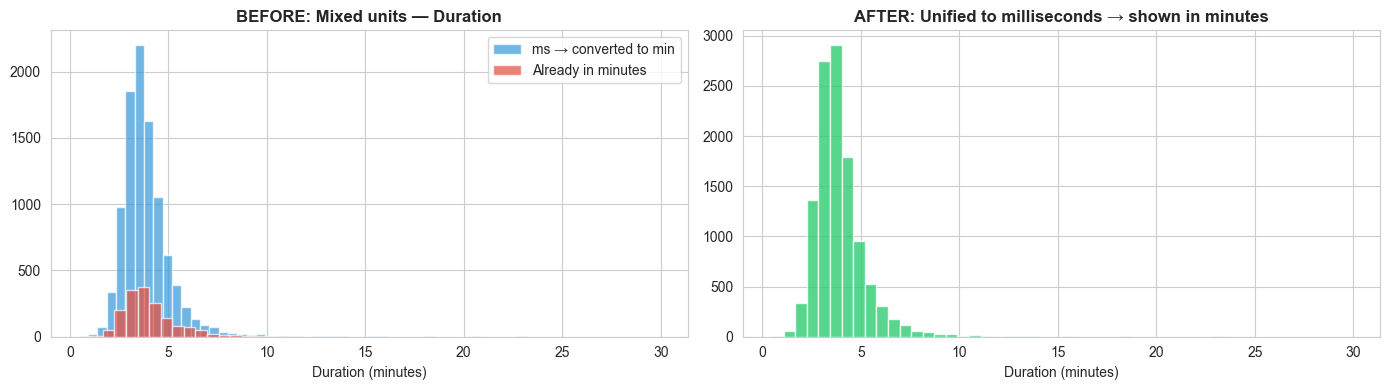


duration_ms: min=0.50 min, max=29.89 min, mean=3.93 min


In [91]:
# Visualize mixed units BEFORE fix
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask_minutes = df['duration_in min/ms'] < 100
mask_ms = df['duration_in min/ms'] >= 100

axes[0].hist(df.loc[mask_ms, 'duration_in min/ms'] / 1000 / 60, bins=50, 
             color='#3498db', alpha=0.7, label='ms → converted to min')
axes[0].hist(df.loc[mask_minutes, 'duration_in min/ms'], bins=50, 
             color='#e74c3c', alpha=0.7, label='Already in minutes')
axes[0].set_title('BEFORE: Mixed units — Duration', fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].legend()

print(f"Values in milliseconds : {mask_ms.sum():,} ({mask_ms.sum()/len(df)*100:.1f}%)")
print(f"Values in minutes      : {mask_minutes.sum():,} ({mask_minutes.sum()/len(df)*100:.1f}%)")

# FIX: Convert minutes → milliseconds
df['duration_in min/ms'] = df['duration_in min/ms'].apply(
    lambda x: x * 60 * 1000 if x < 100 else x
)
df.rename(columns={'duration_in min/ms': 'duration_ms'}, inplace=True)

# Visualize AFTER
axes[1].hist(df['duration_ms'] / 1000 / 60, bins=50, color='#2ecc71', alpha=0.8)
axes[1].set_title('AFTER: Unified to milliseconds → shown in minutes', fontweight='bold')
axes[1].set_xlabel('Duration (minutes)')

plt.tight_layout()
plt.show()

print(f"\nduration_ms: min={df['duration_ms'].min()/60000:.2f} min, "
      f"max={df['duration_ms'].max()/60000:.2f} min, "
      f"mean={df['duration_ms'].mean()/60000:.2f} min")


In [92]:
df.head(10)

,Id,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class
0,12499,Papa Charlie's Boys,You Can't Play Me Cheap,24.0000,0.6920,0.3010,2.0000,-14.0940,0,0.0403,0.9380,0.0000,0.1100,0.7130,92.0590,172042.0000,4,2
1,11873,Rosey,Bermuda Triangle,39.0000,0.5410,0.3920,7.0000,-10.6350,1,0.0445,0.5390,0.0001,0.0864,0.3510,152.9930,225999.0000,4,0
2,11843,Dan + Shay,"10,000 Hours (with Justin Bieber)",84.0000,0.6540,0.6300,10.0000,-4.6440,1,0.0259,0.1530,NaN,0.1110,0.4300,89.9910,167693.0000,4,9
3,3342,Rob Zombie,Two-Lane Blacktop,51.0000,0.5330,0.9820,10.0000,-1.4090,0,0.0910,0.0149,NaN,0.1070,0.6270,142.2760,182667.0000,4,8
4,8593,Wizard,I Bring Light Into the Dark,30.0000,0.4920,0.8840,1.0000,-11.0610,0,0.0909,0.0007,0.0000,0.3170,0.1490,135.0730,297165.0000,4,8
5,6741,Alka Yagnik,Ek Do Teen Char,41.0000,0.4230,0.9030,1.0000,-7.5960,1,0.1490,0.6120,0.0000,0.9230,0.7740,130.6750,457280.0000,4,3
6,6702,Astoria Three,If you could see me now,51.0000,0.5150,0.0999,8.0000,-21.1260,1,0.0405,0.9570,0.8970,0.0928,0.1520,113.5630,272021.0000,4,7
7,14292,Ozzy Osbourne,Ordinary Man (feat. Elton John),59.0000,0.4280,0.5990,4.0000,-2.1350,1,0.0286,0.0665,0.0000,0.1370,0.1340,125.8300,301730.0000,4,8
8,6169,The Jesus and Mary Chain,April Skies,54.0000,0.5450,0.7170,3.0000,-6.8690,1,0.0360,0.0042,0.4060,0.1360,0.5890,118.5150,239621.0000,4,6
9,8903,Nada Surf,Popular,53.0000,0.4440,0.8840,7.0000,-6.1040,1,0.1190,0.0075,0.0001,0.1160,0.2960,94.8200,220587.0000,4,6


In [93]:
df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class
count,11516.0000,11241.0000,11516.0000,11516.0000,10249.0000,11516.0000,11516.0000,11516.0000,11516.0000,8689.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000
mean,7202.1212,44.6447,0.5437,0.6623,5.9697,-7.8961,0.6376,0.0802,0.2467,0.1789,0.1956,0.4848,122.7491,235844.1446,3.9271,6.6957
std,4168.5708,17.4904,0.1656,0.2363,3.2018,4.0538,0.4807,0.0848,0.3112,0.3053,0.1595,0.2398,29.5924,86479.6932,0.3549,3.2060
min,1.0000,1.0000,0.0596,0.0012,1.0000,-39.9520,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,30.5570,30099.0000,1.0000,0.0000
25%,3563.5000,33.0000,0.4320,0.5078,3.0000,-9.5400,0.0000,0.0349,0.0045,0.0001,0.0973,0.2960,99.8328,187532.7500,4.0000,5.0000
50%,7253.5000,44.0000,0.5450,0.6995,6.0000,-7.0100,1.0000,0.0474,0.0811,0.0040,0.1290,0.4790,120.0485,220000.0000,4.0000,8.0000
75%,10819.2500,56.0000,0.6590,0.8600,9.0000,-5.1617,1.0000,0.0832,0.4310,0.2040,0.2550,0.6700,142.0023,262937.0000,4.0000,10.0000
max,14395.0000,100.0000,0.9890,1.0000,11.0000,1.3420,1.0000,0.9370,0.9960,0.9870,0.9920,0.9860,217.4160,1793160.0000,5.0000,10.0000


## Xử lý `loudness`: Giá trị dương

### Vấn đề
Loudness được đo bằng **dB (decibels)**, luôn là **số âm hoặc 0** (0 dB là mức tối đa).  
Dataset có **7 giá trị dương** (0.1 đến 1.342) — rõ ràng là lỗi dữ liệu.

### Phương pháp xử lý
**Đổi dấu** các giá trị dương thành âm, 7 giá trị này nằm trong khoảng (0, 1.4), về mặt giá trị tuyệt đối hoàn toàn hợp lý cho loudness 

Đây là cách đơn giản và có ý nghĩa nhất thay vì xoá hoặc impute.


In [94]:
# Trước khi xử lý
print("Loudness > 0 BEFORE fix:")
print(df[df['loudness'] > 0][['Id', 'loudness']])

# FIX: Chuyển các giá trị dương thành giá trị âm
df.loc[df['loudness'] > 0, 'loudness'] = -df.loc[df['loudness'] > 0, 'loudness']

print(f"\n Loudness range after fix: [{df['loudness'].min():.3f}, {df['loudness'].max():.3f}]")
print(f"   Values > 0 remaining: {(df['loudness'] > 0).sum()}")


Loudness > 0 BEFORE fix:
          Id  loudness
384    13402    0.9430
922    12742    1.3420
7335    2111    0.7320
7366    2303    1.3420
10427   6126    0.1010

 Loudness range after fix: [-39.952, -0.101]
   Values > 0 remaining: 0


In [95]:
# Lưu file sau khi xử lý xong phần giá trị vô lý

now = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"{now}_data_after_Invalid.csv"
filepath = os.path.join("Notebooks", "DataPreprocessing", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)

df.to_csv(filepath, index=False)

print("Saved:", filepath)

Saved: Notebooks\DataPreprocessing\20260520_235922_data_after_Invalid.csv


## Xử lý Missing Values

### Tóm tắt 3 cột bị missing:

| Feature | % Missing | Phân phối | Phương pháp | Lý do |
|---------|-----------|-----------|-------------|-------|
| `Popularity` | 2.31% | Phân phối gần normal (mean≈44.5) | **Median imputation** | Missing ít, median robust với outlier hơn mean |
| `key` | 11.18% | Categorical (integer 1–11) | **Mode imputation** | Biến categorical — dùng giá trị phổ biến nhất |
| `instrumentalness` | 24.60% | Lệch phải nặng (median≈0.004, nhiều bài = 0) | **Median imputation** | Phân phối skewed — median thể hiện đúng trung tâm, tránh bị kéo bởi outlier |

>  **`instrumentalness`:** Missing 24.6% là tỷ lệ đáng kể.  
> Một phương án nâng cao là dùng **KNN Imputer** hoặc **IterativeImputer** dựa trên các feature liên quan (acousticness, energy...)
> 
> Nhưng ở đây, vẫn dùng median để giải quyết. Nhìn vào dataprofiling có thể nhận biết được, trục nó lệch phải, nhưng giá trị = 0 thì chiếm ưu thế vượt trội
> 
> Do đó, vẫn nên dùng nhưng KNN, nhưng để giải quyết trước bài toán, và tối ưu sau. Thì lựa chọn median


In [96]:
df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class
count,11516.0000,11241.0000,11516.0000,11516.0000,10249.0000,11516.0000,11516.0000,11516.0000,11516.0000,8689.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000
mean,7202.1212,44.6447,0.5437,0.6623,5.9697,-7.8969,0.6376,0.0802,0.2467,0.1789,0.1956,0.4848,122.7491,235844.1446,3.9271,6.6957
std,4168.5708,17.4904,0.1656,0.2363,3.2018,4.0523,0.4807,0.0848,0.3112,0.3053,0.1595,0.2398,29.5924,86479.6932,0.3549,3.2060
min,1.0000,1.0000,0.0596,0.0012,1.0000,-39.9520,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,30.5570,30099.0000,1.0000,0.0000
25%,3563.5000,33.0000,0.4320,0.5078,3.0000,-9.5400,0.0000,0.0349,0.0045,0.0001,0.0973,0.2960,99.8328,187532.7500,4.0000,5.0000
50%,7253.5000,44.0000,0.5450,0.6995,6.0000,-7.0100,1.0000,0.0474,0.0811,0.0040,0.1290,0.4790,120.0485,220000.0000,4.0000,8.0000
75%,10819.2500,56.0000,0.6590,0.8600,9.0000,-5.1617,1.0000,0.0832,0.4310,0.2040,0.2550,0.6700,142.0023,262937.0000,4.0000,10.0000
max,14395.0000,100.0000,0.9890,1.0000,11.0000,-0.1010,1.0000,0.9370,0.9960,0.9870,0.9920,0.9860,217.4160,1793160.0000,5.0000,10.0000


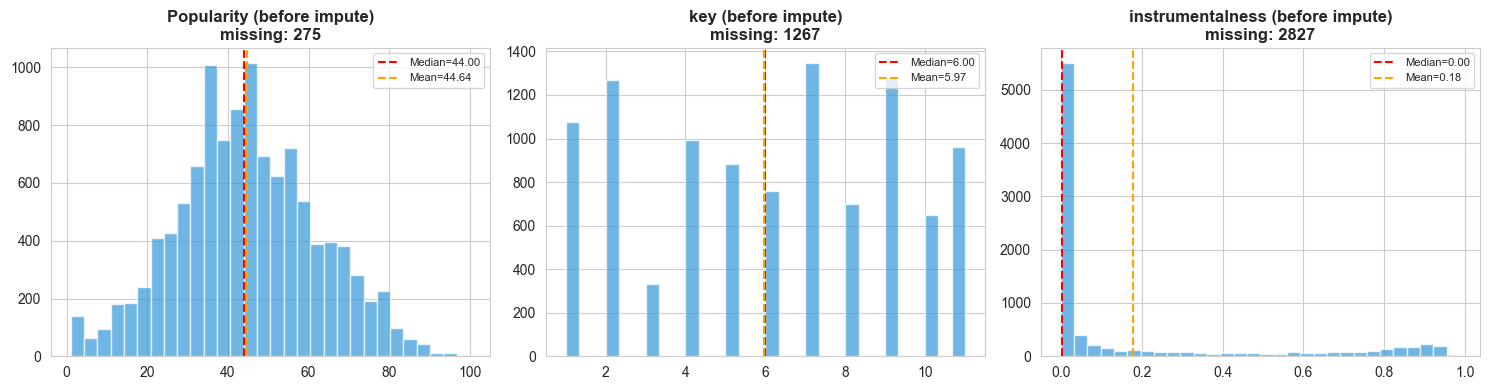

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# BEFORE distributions
for ax, col in zip(axes, ['Popularity', 'key', 'instrumentalness']):
    ax.hist(df[col].dropna(), bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    ax.axvline(df[col].median(), color='red', linestyle='--', label=f'Median={df[col].median():.2f}')
    ax.axvline(df[col].mean(), color='orange', linestyle='--', label=f'Mean={df[col].mean():.2f}')
    ax.set_title(f'{col} (before impute)\nmissing: {df[col].isnull().sum()}', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [98]:

# FIX: Impute missing values
pop_median = df['Popularity'].median()
key_mode   = df['key'].mode()[0]
instr_median = df['instrumentalness'].median()

df['Popularity']        = df['Popularity'].fillna(pop_median)
df['key']               = df['key'].fillna(key_mode)
df['instrumentalness']  = df['instrumentalness'].fillna(instr_median)

# Convert key back to int after fillna
df['key'] = df['key'].astype(int)

print(f" Popularity       — filled {333} NaN  → median = {pop_median}")
print(f" key              — filled {1609} NaN → mode   = {int(key_mode)}")
print(f" instrumentalness — filled {3541} NaN → median = {instr_median:.6f}")
print(f"\nMissing values remaining: {df.isnull().sum().sum()}")


 Popularity       — filled 333 NaN  → median = 44.0
 key              — filled 1609 NaN → mode   = 7
 instrumentalness — filled 3541 NaN → median = 0.003990

Missing values remaining: 0


In [99]:
df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class
count,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000
mean,7202.1212,44.6293,0.5437,0.6623,6.0830,-7.8969,0.6376,0.0802,0.2467,0.1360,0.1956,0.4848,122.7491,235844.1446,3.9271,6.6957
std,4168.5708,17.2806,0.1656,0.2363,3.0377,4.0523,0.4807,0.0848,0.3112,0.2757,0.1595,0.2398,29.5924,86479.6932,0.3549,3.2060
min,1.0000,1.0000,0.0596,0.0012,1.0000,-39.9520,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,30.5570,30099.0000,1.0000,0.0000
25%,3563.5000,33.0000,0.4320,0.5078,4.0000,-9.5400,0.0000,0.0349,0.0045,0.0003,0.0973,0.2960,99.8328,187532.7500,4.0000,5.0000
50%,7253.5000,44.0000,0.5450,0.6995,7.0000,-7.0100,1.0000,0.0474,0.0811,0.0040,0.1290,0.4790,120.0485,220000.0000,4.0000,8.0000
75%,10819.2500,56.0000,0.6590,0.8600,9.0000,-5.1617,1.0000,0.0832,0.4310,0.0565,0.2550,0.6700,142.0023,262937.0000,4.0000,10.0000
max,14395.0000,100.0000,0.9890,1.0000,11.0000,-0.1010,1.0000,0.9370,0.9960,0.9870,0.9920,0.9860,217.4160,1793160.0000,5.0000,10.0000


In [100]:
# Lưu file sau khi xử lý xong phần Missing value

now = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"{now}_data_after_MissingValue.csv"
filepath = os.path.join("Notebooks", "DataPreprocessing", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)

df.to_csv(filepath, index=False)

print("Saved:", filepath)

Saved: Notebooks\DataPreprocessing\20260521_000012_data_after_MissingValue.csv


## Xử lý Outliers

### Phân tích outliers theo IQR (được phân tích ở Univariate):

| Feature | % Outliers | Quyết định |
|---------|-----------|------------|
| `speechiness` | 11.34% | **Giữ nguyên** - nhiều bài rap/spoken word có speechiness cao là hợp lệ |
| `instrumentalness` | 13.48% | **Giữ nguyên** - nhạc instrumental thực sự có giá trị gần 1.0 |
| `liveness` | 5.33% | **Giữ nguyên** - live recording thực sự tồn tại |
| `loudness` | 4.50% | **Winsorize tại 1st–99th percentile** - một số track bất thường rất nhỏ/rất to |
| `duration_ms` | *(kiểm tra)* | **Winsorize** - loại các track cực ngắn (<30s) hoặc cực dài (>1h) |

### Lý do dùng Winsorizing thay vì xóa:
- **Không mất dữ liệu** - hàng được giữ lại, chỉ clip giá trị cực đoan
- **Phù hợp cho ML** - model không bị ảnh hưởng bởi giá trị cực đoan mà thực chất là noise
- Với các feature như `speechiness`, `liveness`, `instrumentalness`: outlier có ý nghĩa âm nhạc thực sự (vì nó có thật chỉ đặc thù chứ không phải không có)-> **không xử lý**


Winsorizing (1st–99th percentile):
---------------------------------------------------------------------------
loudness             before [-39.952, -0.101] → after [-22.637, -2.135] | clipped: 233 rows
duration_ms          before [30099.000, 1793160.000] → after [112843.450, 526986.400] | clipped: 232 rows
tempo                before [30.557, 217.416] → after [70.975, 193.987] | clipped: 232 rows


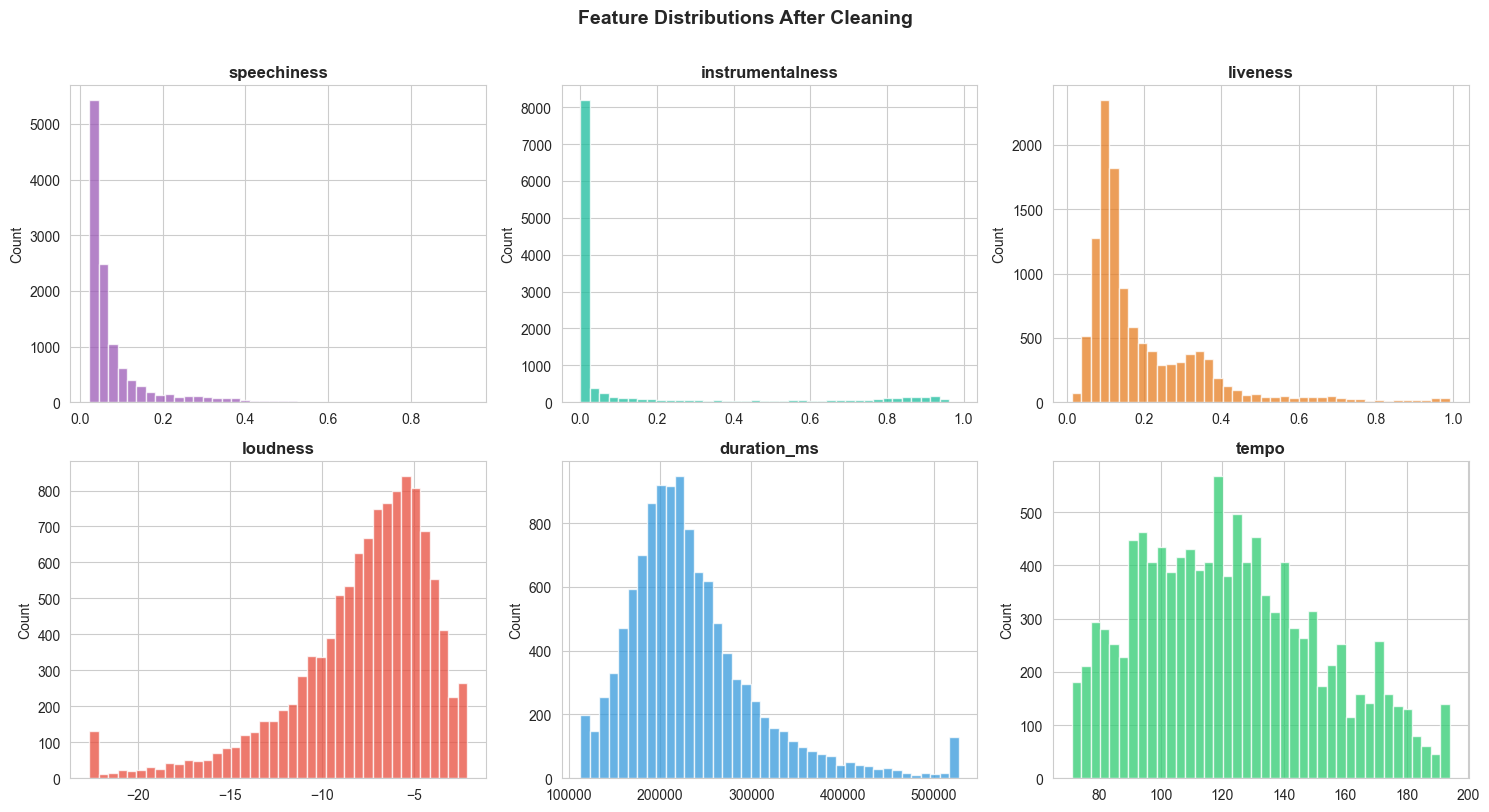

In [101]:
def winsorize_col(df, col, lower=0.01, upper=0.99):
    """Clip giá trị về [lower_pct, upper_pct] percentile"""
    lo = df[col].quantile(lower)
    hi = df[col].quantile(upper)
    before_min, before_max = df[col].min(), df[col].max()
    df[col] = df[col].clip(lo, hi)
    affected = ((df[col] == lo) | (df[col] == hi)).sum()
    print(f"{col:20s} before [{before_min:.3f}, {before_max:.3f}] "
          f"→ after [{lo:.3f}, {hi:.3f}] | clipped: {affected} rows")
    return df

cols_to_winsorize = ['loudness', 'duration_ms', 'tempo']
print("Winsorizing (1st–99th percentile):")
print("-" * 75)
for col in cols_to_winsorize:
    df = winsorize_col(df, col)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
feature_pairs = [
    ('speechiness', '#9b59b6'),
    ('instrumentalness', '#1abc9c'),
    ('liveness', '#e67e22'),
    ('loudness', '#e74c3c'),
    ('duration_ms', '#3498db'),
    ('tempo', '#2ecc71'),
]
for ax, (col, color) in zip(axes.flatten(), feature_pairs):
    ax.hist(df[col], bins=40, color=color, alpha=0.75, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions After Cleaning', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [103]:
df.describe()

,Id,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class
count,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000
mean,7202.1212,44.6293,0.5437,0.6623,6.0830,-7.8643,0.6376,0.0802,0.2467,0.1360,0.1956,0.4848,122.7396,234063.4749,3.9271,6.6957
std,4168.5708,17.2806,0.1656,0.2363,3.0377,3.8721,0.4807,0.0848,0.3112,0.2757,0.1595,0.2398,29.2479,72661.8926,0.3549,3.2060
min,1.0000,1.0000,0.0596,0.0012,1.0000,-22.6372,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,70.9753,112843.4500,1.0000,0.0000
25%,3563.5000,33.0000,0.4320,0.5078,4.0000,-9.5400,0.0000,0.0349,0.0045,0.0003,0.0973,0.2960,99.8328,187532.7500,4.0000,5.0000
50%,7253.5000,44.0000,0.5450,0.6995,7.0000,-7.0100,1.0000,0.0474,0.0811,0.0040,0.1290,0.4790,120.0485,220000.0000,4.0000,8.0000
75%,10819.2500,56.0000,0.6590,0.8600,9.0000,-5.1617,1.0000,0.0832,0.4310,0.0565,0.2550,0.6700,142.0023,262937.0000,4.0000,10.0000
max,14395.0000,100.0000,0.9890,1.0000,11.0000,-2.1350,1.0000,0.9370,0.9960,0.9870,0.9920,0.9860,193.9867,526986.4000,5.0000,10.0000


In [104]:
# Lưu file sau khi xử lý xong phần các giá trị ngoại lai

now = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"{now}_data_after_Outliers.csv"
filepath = os.path.join("Notebooks", "DataPreprocessing", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)

df.to_csv(filepath, index=False)

print("Saved:", filepath)

Saved: Notebooks\DataPreprocessing\20260521_002352_data_after_Outliers.csv


## Xử lý Categorical & Structural Features

### `key` và `mode`
- `key` (0–11): Mang tính **cyclical** (C = 0, C# = 1, ... B = 11, rồi lại về C).  
  → **Cyclical encoding** (sin/cos transform) để model hiểu C và B là gần nhau.
- `mode` (0/1): Binary, đã đúng format — giữ nguyên.

### Drop columns không cần thiết
- `Id`: Chỉ là index, không có predictive power.
- `Artist Name`, `Track Name`: Text features - cần NLP riêng; drop cho ML pipeline cơ bản.


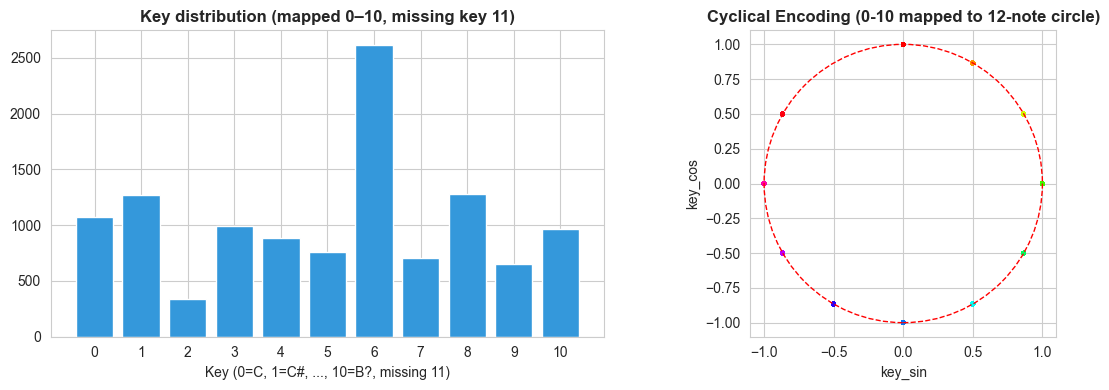

In [113]:
# Mapping key từ 1-11 về 0-10 (vẫn thiếu 1 giá trị, nhưng ít nhất bắt đầu từ 0)
# df['key_standard'] = df['key'] - 1  # Giờ có key từ 0 đến 10

# Cyclical encoding cho 12 cung, nhưng chỉ với 11 giá trị
df['key_sin'] = np.sin(2 * np.pi * df['key_standard'] / 12)
df['key_cos'] = np.cos(2 * np.pi * df['key_standard'] / 12)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

key_counts = df.groupby('key_standard')['key_standard'].count()
axes[0].bar(key_counts.index, key_counts.values, color='#3498db')
axes[0].set_title('Key distribution (mapped 0–10, missing key 11)', fontweight='bold')
axes[0].set_xlabel('Key (0=C, 1=C#, ..., 10=B?, missing 11)')
axes[0].set_xticks(range(0, 11))

axes[1].scatter(df['key_sin'], df['key_cos'], 
                c=df['key_standard'], cmap='hsv', alpha=0.3, s=5)
axes[1].set_title('Cyclical Encoding (0-10 mapped to 12-note circle)', fontweight='bold')
axes[1].set_xlabel('key_sin')
axes[1].set_ylabel('key_cos')
axes[1].set_aspect('equal')
axes[1].add_patch(plt.Circle((0, 0), 1, fill=False, color='red', linestyle='--'))

df.drop(columns=['key_standard'], inplace=True)

plt.tight_layout()
plt.show()

## Sinh ra `key_sin` và `key_cos` từ key?

**Mục đích:** Chuyển `key` từ dạng rời rạc (1, 2, 3, ...) thành dạng liên tục trên vòng tròn để model hiểu được **tính tuần hoàn** của key.

- Nếu để nguyên, model sẽ hiểu `key = 1` gần `key = 2` hơn `key = 11`.
- Nhưng về mặt âm nhạc:
  - `key = 11` (B) và `key = 0` (C) chỉ cách nhau **1 nửa cung** (rất gần)
  - `key = 11` (B) và `key = 6` (F#) cách xa **6 nửa cung**
- Dạng số tuyến tính (1, 2, 3, ...) **phá vỡ mối quan hệ vòng tròn** của key.

### Cyclical encoding giải quyết bằng cách:

1. **Đặt mỗi key là một điểm trên vòng tròn 360°**
2. **Dùng `sin` / `cos` để biểu diễn tọa độ (x, y) của điểm đó**
3. Khi đó:
   - `key = 11` (góc 300°) và `key = 0` (góc 0° / 360°) có tọa độ **gần nhau**
   - Vì 300° và 360° có `sin` / `cos` gần giống nhau

### Kết quả:

| Key | Góc | sin | cos |
|-----|------|-----|-----|
| 0 (C) | 0° | 0 | 1 |
| 1 (C#) | 30° | 0.5 | 0.866 |
| ... | ... | ... | ... |
| 11 (B) | 330° | -0.5 | 0.866 |

→ `key = 0` và `key = 11` có tọa độ gần nhau → model học được **tính tuần hoàn** của âm nhạc.

In [114]:
df.describe()

,Popularity,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,Class,key_sin,key_cos
count,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000,11516.0000
mean,44.6293,0.5437,0.6623,-7.8643,0.6376,0.0802,0.2467,0.1360,0.1956,0.4848,122.7396,234063.4749,3.9271,6.6957,0.0102,-0.1861
std,17.2806,0.1656,0.2363,3.8721,0.4807,0.0848,0.3112,0.2757,0.1595,0.2398,29.2479,72661.8926,0.3549,3.2060,0.6533,0.7338
min,1.0000,0.0596,0.0012,-22.6372,0.0000,0.0225,0.0000,0.0000,0.0119,0.0215,70.9753,112843.4500,1.0000,0.0000,-1.0000,-1.0000
25%,33.0000,0.4320,0.5078,-9.5400,0.0000,0.0349,0.0045,0.0003,0.0973,0.2960,99.8328,187532.7500,4.0000,5.0000,-0.8660,-0.8660
50%,44.0000,0.5450,0.6995,-7.0100,1.0000,0.0474,0.0811,0.0040,0.1290,0.4790,120.0485,220000.0000,4.0000,8.0000,0.0000,-0.5000
75%,56.0000,0.6590,0.8600,-5.1617,1.0000,0.0832,0.4310,0.0565,0.2550,0.6700,142.0023,262937.0000,4.0000,10.0000,0.5000,0.5000
max,100.0000,0.9890,1.0000,-2.1350,1.0000,0.9370,0.9960,0.9870,0.9920,0.9860,193.9867,526986.4000,5.0000,10.0000,1.0000,1.0000


## Tổng kết & Đánh giá kết quả

### Checklist các vấn đề đã xử lý

| # | Vấn đề | Phương pháp | Kết quả |
|---|--------|-------------|---------|
| 1 | `Popularity` missing 2.31% | Median imputation |  0 missing |
| 2 | `key` missing 11.18% | Mode imputation | 0 missing |
| 3 | `instrumentalness` missing 24.60% | Median imputation | 0 missing |
| 4 | `duration_in min/ms` mixed units | Convert phút → ms, rename `duration_ms` | Unified units |
| 5 | `loudness` 7 giá trị dương | Negate (đổi dấu) | Tất cả ≤ 0 |
| 6 | `loudness`, `duration_ms`, `tempo` outliers | Winsorize 1–99th pct | Clipped |
| 7 | `key` cyclical nature | Sin/Cos encoding |`key_sin`, `key_cos` |
| 8 | Non-predictive columns | Drop `Id`, `Artist Name`, `Track Name` | Removed |

### Lưu ý & Bước tiếp theo

1. **Class Imbalance**: Class 10 chiếm 27.5%, Class 3/4 chỉ ~2%.  
   → Cân nhắc **SMOTE**, **class_weight='balanced'**, hoặc **stratified sampling** khi train.

2. **`instrumentalness` imputation**: 24.6% missing là nhiều.  
   → Nếu cần accuracy cao hơn, thử **KNNImputer** hoặc **IterativeImputer**.

3. **Feature Scaling**: Chưa scale — cần **StandardScaler** hoặc **MinMaxScaler** trước khi dùng distance-based models (SVM, KNN, Logistic Regression).

4. **`speechiness`, `liveness`, `instrumentalness`**: Outliers giữ nguyên vì có ý nghĩa âm nhạc thực tế.
